# Per-galaxy chi-squared and star-formation-timescale diagnostics

- Read every DR2 target folder; rebuild its `SedModel`; compare with the stored fit.
- Two chi-squared definitions: stored (posterior-median model) and at theta_ML (fit's own sigma).
- t_X: lookback time by which X percent of the final mass had formed.
- Every figure carries the model statement generated from the model object.

## Setup
- Import the diagnostics module from `scripts/`.
- Paths default to the DR2 production run.

In [1]:
import os
import sys
from pathlib import Path

os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import per_galaxy_diagnostics as pgd  # noqa: E402

RUN_DIR = pgd.DEFAULT_RUN_DIR
OUT_CSV = pgd.DEFAULT_OUT_CSV
SUMMARY_DIR = pgd.DEFAULT_SUMMARY_DIR
EXAMPLE = "M1_210210"
pd.set_option("display.width", 200)
print(RUN_DIR)

/Users/liuhao/Downloads/Astro project/results/rtx-5060-dr2-quiescent-full-spectrum


## Run the diagnostics for every galaxy
- Writes three figures and the parameter block into `<target>/diagnostics/`.
- One CSV row per galaxy; two cross-galaxy figures.

In [2]:
table = pgd.run(RUN_DIR, OUT_CSV, SUMMARY_DIR, log=lambda message: None)
print(f"{len(table)} galaxies -> {OUT_CSV}")
table[["target", "z", "catalogue_sn", "phot_redchi2_stored", "spec_redchi2_stored",
       "f_calib_median_pct", "lnl_ml_diff", "t50_q50", "flags"]].head(8)

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 2% of pixels over [5247, 5554] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 4% of pixels over [5248, 5963] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


...

/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 3% of pixels over [5249, 5829] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 4% of pixels over [5248, 5945] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


187 galaxies -> /Users/liuhao/Downloads/Astro project/results/per-galaxy-diagnostics.csv


,target,z,catalogue_sn,phot_redchi2_stored,spec_redchi2_stored,f_calib_median_pct,lnl_ml_diff,t50_q50,flags
0,101089-M12_101089,0.851000,8.300000,1.484778,2.340154,9.994335,1.970564,5.236584,spectrum chi2/N 2.34 > 1.5; calibration floor ...
1,101830-M12_101830,0.987383,11.300000,6.948827,1.536759,9.982776,-0.449962,3.224914,photometry chi2/N 6.9 > 3; spectrum chi2/N 1.5...
2,102456-M12_102456,0.677949,34.900002,14.218891,1.190866,5.896951,-6.563506,3.607076,photometry chi2/N 14.2 > 3; 10 pixels with |pu...
3,102968-M14_102968,0.939345,9.500000,12.496433,1.098601,5.927012,-1.743334,3.559511,photometry chi2/N 12.5 > 3; 1 pixels with |pul...
4,103366-M14_103366,0.674206,14.300000,2.919522,1.133146,5.252348,-0.423069,3.429412,3 pixels with |pull| > 4
5,104877-M14_104877,0.954400,3.600000,7.385788,1.775956,9.971184,-0.097257,0.054345,photometry chi2/N 7.4 > 3; spectrum chi2/N 1.7...
6,105474-M4_105474,0.673200,37.299999,13.037360,1.095371,5.845476,-4.074002,0.798842,photometry chi2/N 13.0 > 3; 3 pixels with |pul...
7,107362-M3_107362,0.676700,23.700001,13.981872,1.155393,4.335100,-1.090202,2.999311,photometry chi2/N 14.0 > 3; 3 pixels with |pul...


## Checks against the fit inputs
- Stored masks, sigma and ndof must equal the observation arrays the sampler used.
- Stored pulls and chi-squared totals must follow their own definitions.
- The rebuilt likelihood at theta_ML is compared with the stored log-likelihood.

effective-sigma rebuild, max relative difference: 3.20e-03
ln L recomputed - stored at theta_ML: median -1.39, 16-84% [-4.03, +0.25], range [-10.72, +4.60]; |diff| > 5 for 16 galaxies
spectrum chi2 at theta_ML vs stored: median +0.0012, max |rel| 0.0201
photometry chi2 at theta_ML vs stored: median +0.001, max |rel| 0.574


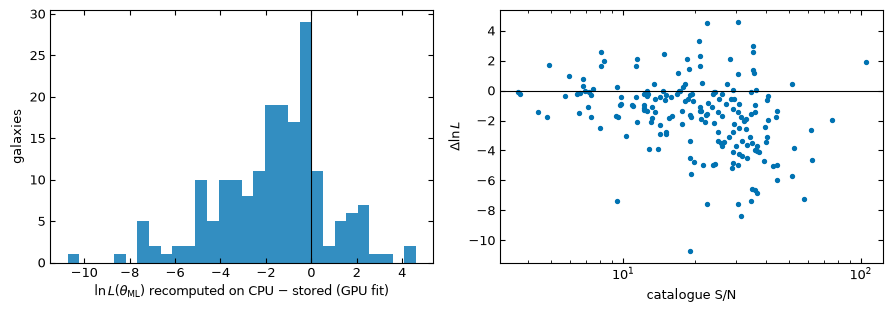

In [3]:
assert table["mask_match"].all(), "a stored mask differs from the fit's observation mask"
assert table["sigma_match"].all(), "a stored sigma differs from the fit's observation sigma"
assert table["ndof_h5_match"].all() and table["ml_ndof_match"].all()
assert table["pull_recompute_max_abs_diff"].max() == 0.0
assert table["chi2_h5_recompute_max_abs_diff"].max() < 1e-6
print("effective-sigma rebuild, max relative difference:",
      f"{table['eff_sigma_max_rel_diff'].max():.2e}")
diff = table["lnl_ml_diff"]
print("ln L recomputed - stored at theta_ML: "
      f"median {diff.median():+.2f}, 16-84% [{diff.quantile(0.16):+.2f}, {diff.quantile(0.84):+.2f}], "
      f"range [{diff.min():+.2f}, {diff.max():+.2f}]; |diff| > 5 for {(diff.abs() > 5).sum()} galaxies")
rel_spec = (table["spec_chi2_ml"] - table["spec_chi2_stored"]) / table["spec_chi2_stored"]
rel_phot = (table["phot_chi2_ml"] - table["phot_chi2_stored"]) / table["phot_chi2_stored"]
print(f"spectrum chi2 at theta_ML vs stored: median {rel_spec.median():+.4f}, max |rel| {rel_spec.abs().max():.4f}")
print(f"photometry chi2 at theta_ML vs stored: median {rel_phot.median():+.3f}, max |rel| {rel_phot.abs().max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(diff, bins=30, color=pgd.BLUE, alpha=0.8)
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel(r"$\ln L(\theta_{\rm ML})$ recomputed on CPU $-$ stored (GPU fit)")
axes[0].set_ylabel("galaxies")
axes[1].scatter(table["catalogue_sn"], diff, s=8, color=pgd.BLUE)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xscale("log")
axes[1].set_xlabel("catalogue S/N")
axes[1].set_ylabel(r"$\Delta \ln L$")
plt.tight_layout()
plt.show()

## Example galaxy
- The three figures for M1_210210, inline.
- The model parameter block generated from the rebuilt model object.

In [4]:
folder = next(RUN_DIR.glob(f"*-{EXAMPLE}"))
galaxy = pgd.load_galaxy(folder)
ssp = pgd.load_ssp()
model, likelihood, _ = pgd.rebuild_model(galaxy, ssp)
like_ml = pgd.likelihood_terms(model, likelihood, pgd.theta_at(galaxy, pgd.max_likelihood_index(galaxy)))
stamp = pgd.model_stamp(model, ssp, likelihood, galaxy.settings, galaxy.seed)
print(pgd.model_parameter_block(model, ssp, likelihood, galaxy.settings, galaxy.seed))

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)
MODEL PARAMETERS (generated from the SedModel object)
Stellar population grid
  library: C3K v2.3 high-res (c3k_hr, vt=10 km/s); isochrones: MIST v2.5 (aMIST, alpha-variable); IMF: imf_type=2 (Kroupa (2001)); schema 2.1
  grid axes: [alpha/Fe] [-0.2, 0, 0.2, 0.4, 0.6]; log10 Z 13 nodes [-4.233, -1.233] (absolute Z); log10(age/Gyr) 107 nodes; wavelength 10992 pts [100, 99595855] A
Star-formation history
  form: piecewise-constant SFR ('step' interpolation) on 7 lookback bins; metallicity history: constant Z
  bin edges (lookback, Gyr): [0, 0.03, 0.1, 0.3, 1, 3, 5, 7.566]  (last edge = universe age at z)
  free parameters: logsfr_ratios[7] = log10(SFR_i / SFR_i+1), transform 'sfh_from_ratios' -> unit-mass SFH (integral 1 Msun); logmass scales the total formed mass
Free parameters and priors
  Z: shape (1,); prior Uniform(-

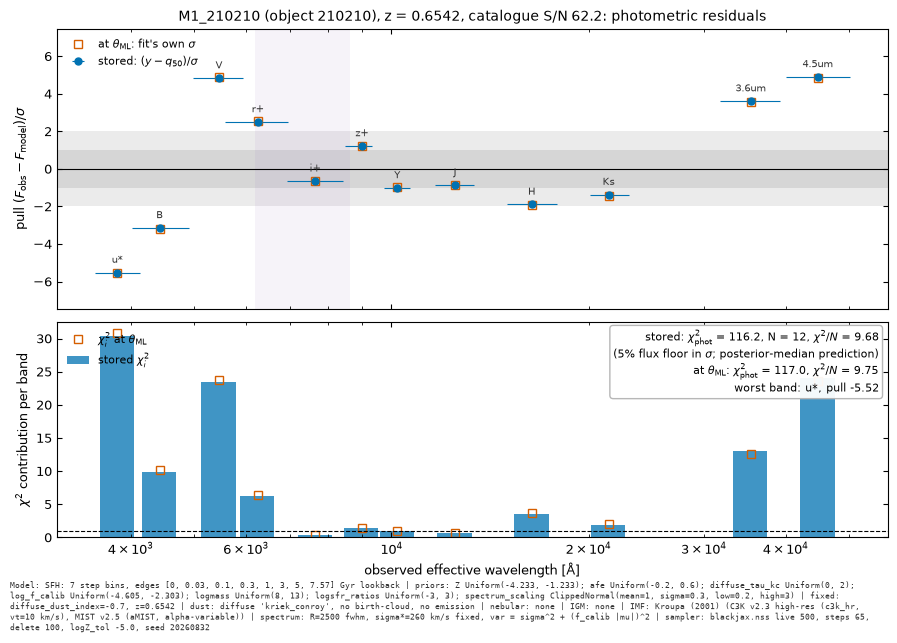

In [5]:
pgd.plot_photometric_chi2(galaxy, model, like_ml, stamp)
plt.show()

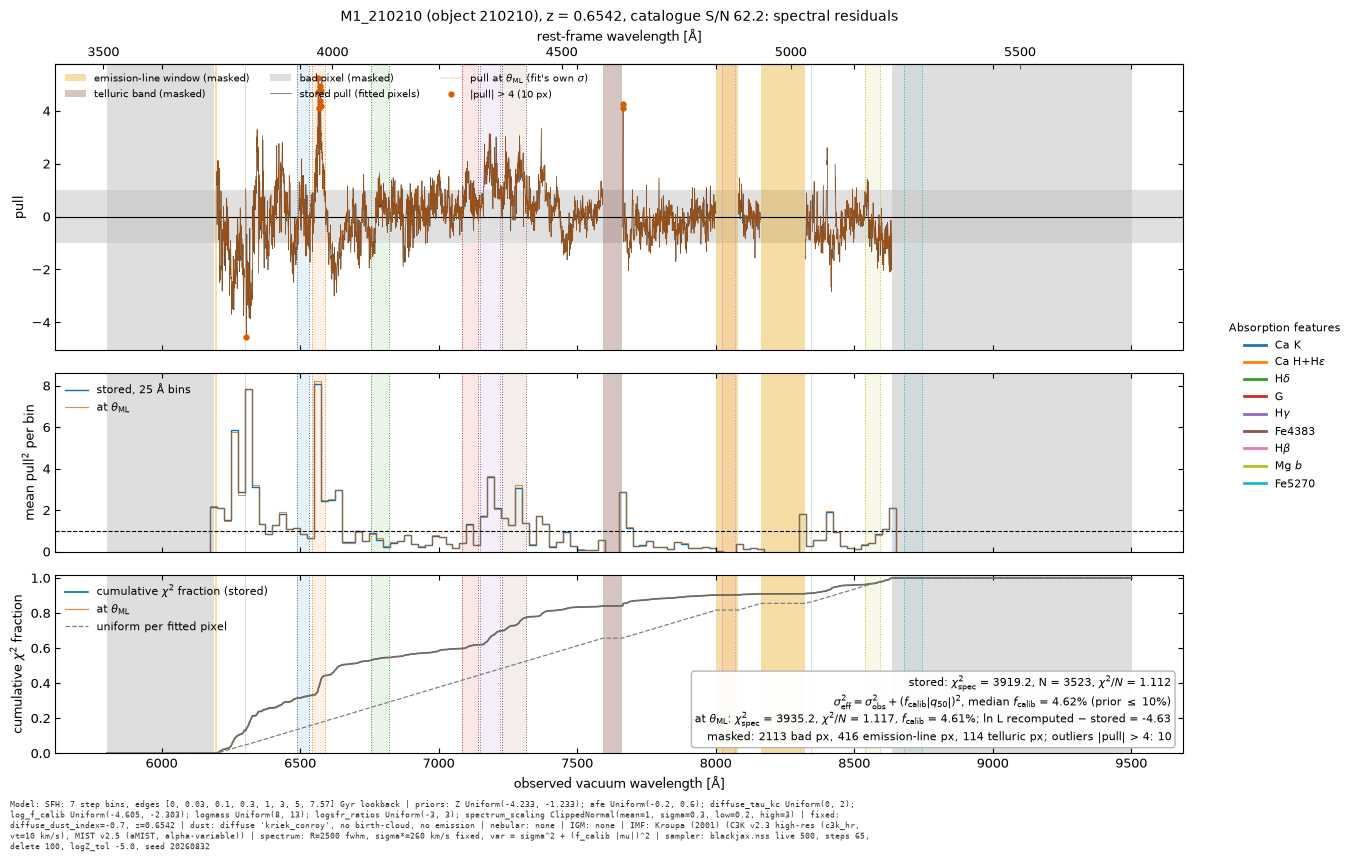

In [6]:
pgd.plot_spectral_chi2(galaxy, like_ml, stamp)
plt.show()

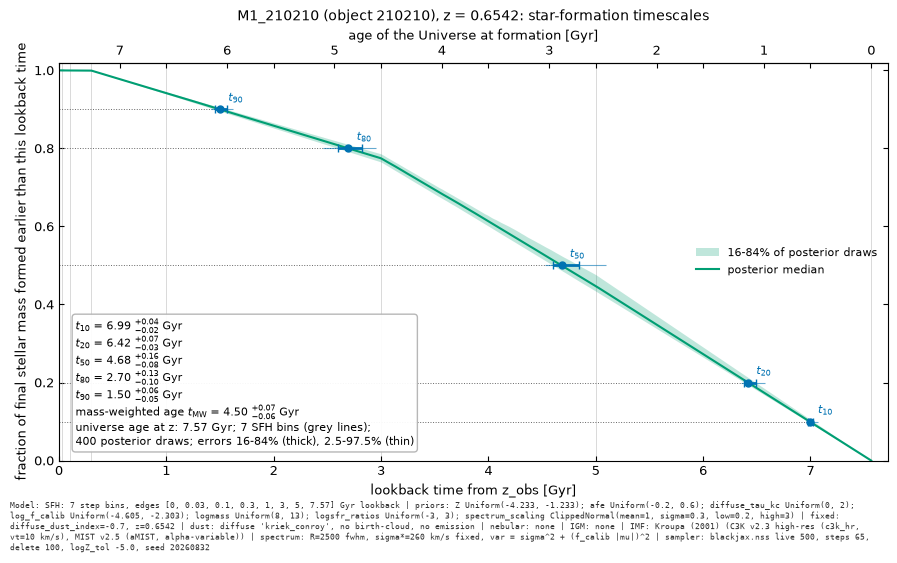

In [7]:
pgd.plot_sf_timescales(galaxy, stamp)
plt.show()

## Flags
- Photometry chi2/N above 3; spectrum chi2/N above 1.5.
- Calibration floor within 2 percent of its 10 percent prior bound.
- Pixels with |pull| above 4.

In [8]:
flags = table["flags"].fillna("")
print(f"no flag: {(flags == '').sum()}; photometry: {flags.str.contains('photometry').sum()}; "
      f"spectrum: {flags.str.contains('spectrum chi2').sum()}; calibration floor: {flags.str.contains('calibration').sum()}; "
      f"outlier pixels: {flags.str.contains('pixels with').sum()}")
columns = ["target", "z", "catalogue_sn", "phot_redchi2_stored", "spec_redchi2_stored",
           "f_calib_median_pct", "n_outlier_pixels", "worst_band", "worst_band_pull"]
print("calibration floor at the prior bound:")
display(table[table["calib_saturated"]][columns].sort_values("spec_redchi2_stored", ascending=False))
print("worst photometric chi2/N:")
display(table.sort_values("phot_redchi2_stored", ascending=False)[columns].head(10))

no flag: 3; photometry: 157; spectrum: 10; calibration floor: 17; outlier pixels: 173
calibration floor at the prior bound:


,target,z,catalogue_sn,phot_redchi2_stored,spec_redchi2_stored,f_calib_median_pct,n_outlier_pixels,worst_band,worst_band_pull
47,139662-M2_139662,0.670600,17.299999,3.873520,2.684886,9.997890,82,V,4.576290
157,253688-M13_253688,0.837035,4.800000,1.887305,2.554125,9.991250,65,4.5um,1.987162
0,101089-M12_101089,0.851000,8.300000,1.484778,2.340154,9.994335,57,V,2.265798
74,185631-M12_185631,0.925326,4.900000,1.990502,1.804040,9.986709,13,r+,2.660153
5,104877-M14_104877,0.954400,3.600000,7.385788,1.775956,9.971184,19,V,-5.992717
106,216899-M11_216899,0.697825,21.100000,3.749969,1.712585,9.994150,12,4.5um,3.340632
186,98104-M12_98104,0.981417,6.600000,4.058789,1.554316,9.981169,14,H,-3.387318
147,244680-M13_244680,0.957562,4.400000,3.660650,1.548794,9.975465,13,B,-3.782960
1,101830-M12_101830,0.987383,11.300000,6.948827,1.536759,9.982776,24,4.5um,4.592392
162,259737-M13_259737,0.702821,14.700000,8.563597,1.526805,9.990636,32,4.5um,6.183219


worst photometric chi2/N:


,target,z,catalogue_sn,phot_redchi2_stored,spec_redchi2_stored,f_calib_median_pct,n_outlier_pixels,worst_band,worst_band_pull
121,228380-M10_228380,0.611376,36.099998,28.770911,1.133404,3.248010,5,4.5um,11.056395
82,205765-M5_205765,0.728700,14.300000,25.617344,1.040164,4.823190,5,B,-9.024854
16,113852-M7_113852,0.675200,39.500000,24.530637,1.148701,4.225585,7,4.5um,10.150611
111,221163-M11_221163,0.697538,34.200001,22.977535,1.106213,4.835031,4,B,-9.553959
83,206501-M1_206501,0.926200,30.500000,22.938619,1.145404,5.433849,17,u*,7.241406
149,245252-M11_245252,0.694377,44.200001,22.753913,1.102323,4.230141,16,4.5um,11.202837
45,134391-M2_134391,0.683500,44.599998,19.580067,1.136680,2.901462,5,4.5um,8.339300
156,250391-M11_250391,0.889261,35.799999,18.539076,1.083260,4.680996,17,u*,7.923656
97,213004-M11_213004,0.746492,39.400002,18.374333,1.125213,4.574288,10,4.5um,9.943899
104,215585-M11_215585,0.748731,35.599998,17.501907,1.145338,4.649113,5,B,-9.531643


## Formation timescales across the sample
- t_X here mirrors the summary CSV: t20 here equals t80 there, t50 equals t50.
- Values are quantised by the 7-bin SFH; treat them as resolution-limited.

sample medians [Gyr]: t10 4.64, t20 4.23, t50 3.02, t80 1.80, t90 1.39
median 16-84 half-width [Gyr]: t10 0.08, t20 0.09, t50 0.09, t80 0.06, t90 0.04


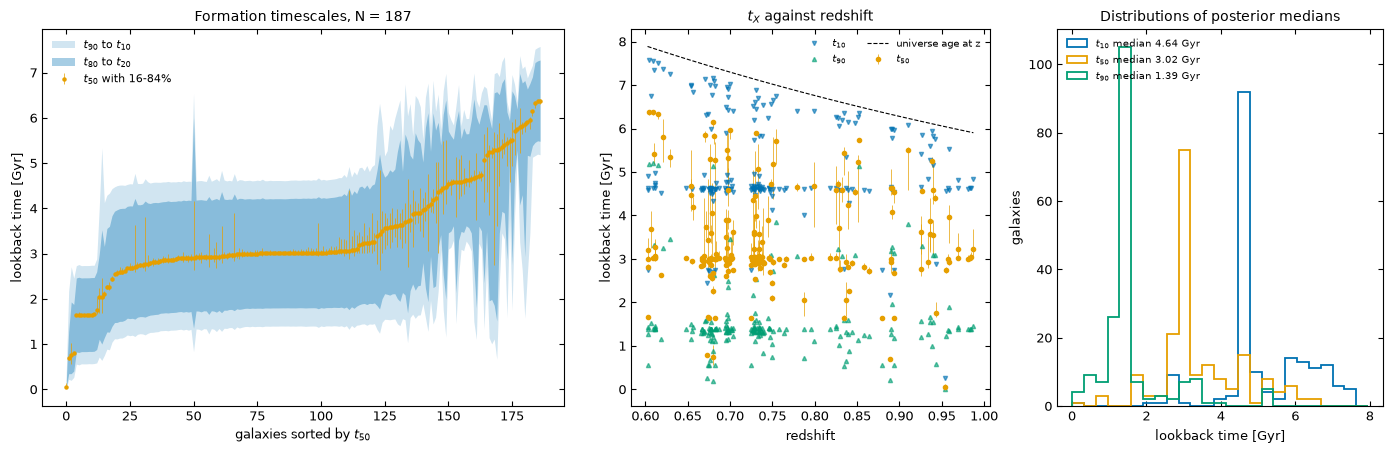

In [9]:
summary = pd.read_csv(PROJECT_ROOT / "results/dr2-quiescent-summary.csv")
merged = table.merge(summary[["target", "t20_q50", "t50_q50", "t80_q50"]], on="target", suffixes=("", "_csv"))
assert np.allclose(merged["t50_q50"], merged["t50_q50_csv"])
assert np.allclose(merged["t20_q50"], merged["t80_q50_csv"])
assert np.allclose(merged["t80_q50"], merged["t20_q50_csv"])
print("sample medians [Gyr]: " + ", ".join(f"t{x} {table[f't{x}_q50'].median():.2f}" for x in (10, 20, 50, 80, 90)))
print("median 16-84 half-width [Gyr]: " + ", ".join(
    f"t{x} {((table[f't{x}_q84'] - table[f't{x}_q16']) / 2).median():.2f}" for x in (10, 20, 50, 80, 90)))
pgd.plot_sf_timescale_summary(table)
plt.show()

## Photometry across the sample
- Median pull and mean chi-squared per band over all galaxies.

,band,wavelength,pull_median,pull_q16,pull_q84,chi2_mean,frac_abs_pull_gt2
0,u*,3813.241,-0.592,-2.915,0.765,5.846,0.299
1,B,4427.215,-1.674,-4.640,0.109,11.224,0.476
2,V,5454.852,1.595,0.319,2.755,4.794,0.396
3,r+,6248.965,-0.083,-1.632,2.777,5.014,0.353
4,i+,7645.871,-1.946,-2.975,1.616,6.763,0.604
5,z+,9010.843,0.232,-0.491,2.497,3.513,0.209
6,Y,10204.728,-1.760,-2.533,-0.374,3.835,0.439
7,J,12504.930,-1.016,-1.867,-0.431,1.867,0.118
8,H,16388.522,-0.971,-2.579,0.267,3.402,0.257
9,Ks,21452.791,0.665,-1.489,2.178,4.045,0.310


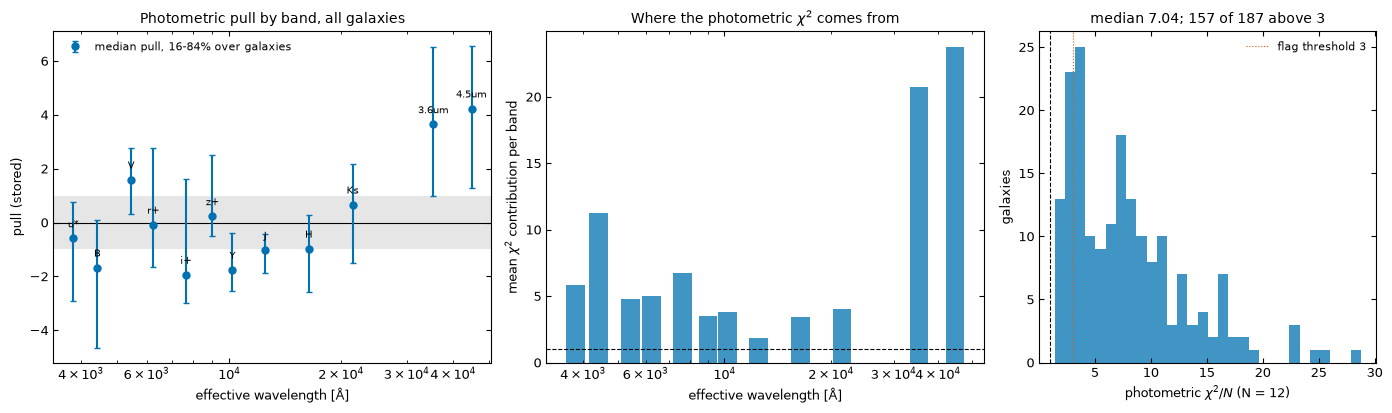

In [10]:
bands = pgd.band_summary(table, galaxy.phot["filters"])
display(bands.round(3))
pgd.plot_photometry_summary(bands, table)
plt.show()